cell 1


In [ ]:
#   CNN-LSTM training camera
#   all data is normlised before training
#   11 joints used in training
#   [R_Shoulder, L_Shoulder, R_Elbow, L_Elbow, R_Wrist, L_Wrist,
#   R_Hip, L_Hip, R_Knee, L_Knee, Nose]


!pip install -q tensorflow scikit-learn scipy matplotlib seaborn

import os, zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Reshape, Conv1D, MaxPooling1D,
                                     LSTM, Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from google.colab import files

print("All imports done")

All imports done


CELL 2

In [ ]:
print("Upload TENNIS_CLEAN.zip now")
uploaded = files.upload()

zip_name = [f for f in uploaded.keys() if f.endswith('.zip')][0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("TENNIS_DATA")

print("Extracted folders:")
for item in os.listdir("TENNIS_DATA"):
    print(f"  {item}")

Upload TENNIS_CLEAN.zip now...


Saving TENNIS_CLEAN.zip to TENNIS_CLEAN.zip
Extracted folders:
  TENNIS_CLEAN


CELL 3

In [ ]:
TARGET_FRAMES = 30
R_HIP_IDX = 6
L_HIP_IDX = 7

def load_folder(folder, label):
    X_list, y_list = [], []
    bad = 0
    for f in sorted(os.listdir(folder)):
        if not f.endswith(".npy"):
            continue
        data = np.load(os.path.join(folder, f))


        if data.ndim == 2:
            data = data.reshape(-1, 11, 2)


          if data.shape[0] != TARGET_FRAMES:
            data = resample(data, TARGET_FRAMES, axis=0)


        hip_mid = (data[:, R_HIP_IDX, :] + data[:, L_HIP_IDX, :]) / 2.0
        data = data - hip_mid[:, np.newaxis, :]


        data = data.reshape(TARGET_FRAMES, 22).astype(np.float32)
        X_list.append(data)
        y_list.append(label)

    return X_list, y_list


def find_folder(name):
    for root, dirs, _ in os.walk("TENNIS_DATA"):
        for d in dirs:
            if name in d:
                return os.path.join(root, d)
    return None

F_PATH = find_folder("forehand_v2")
B_PATH = find_folder("backhand_v3")
S_PATH = find_folder("serve_v3")

print(f"Forehand: {F_PATH}")
print(f"Backhand: {B_PATH}")
print(f"Serve:    {S_PATH}")

X, y = [], []
for path, label, name in [(F_PATH,0,"Forehand"),(B_PATH,1,"Backhand"),(S_PATH,2,"Serve")]:
    xf, yf = load_folder(path, label)
    X += xf
    y += yf
    print(f"  {name}: {len(xf)} clips loaded")

X = np.array(X)
y = np.array(y)
print(f"\n Raw dataset: {X.shape}  labels: {y.shape}")
print(f"   Class counts: F={np.sum(y==0)}  B={np.sum(y==1)}  S={np.sum(y==2)}")

Forehand: TENNIS_DATA/TENNIS_CLEAN/forehand_v2_resampled
Backhand: TENNIS_DATA/TENNIS_CLEAN/backhand_v3_resampled
Serve:    TENNIS_DATA/TENNIS_CLEAN/serve_v3_resampled
  Forehand: 48 clips loaded
  Backhand: 49 clips loaded
  Serve: 47 clips loaded

 Raw dataset: (144, 30, 22)  labels: (144,)
   Class counts: F=48  B=49  S=47


CELL 4

In [ ]:

X_train_orig, X_val, y_train_orig, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def flip_horizontal(seq):
    flipped = seq.copy()
    flipped[:, 0::2] = -flipped[:, 0::2]
    return flipped

def add_noise(seq, scale=0.005):
    """Small random noise — prevents exact memorization"""
    return seq + np.random.normal(0, scale, seq.shape).astype(np.float32)

X_aug, y_aug = [], []
for seq, label in zip(X_train_orig, y_train_orig):

    flipped = flip_horizontal(seq)
    X_aug.append(flipped)
    y_aug.append(1 if label==0 else (0 if label==1 else 2))


    X_aug.append(add_noise(seq))
    y_aug.append(label)


    X_aug.append(add_noise(flipped))
    y_aug.append(1 if label==0 else (0 if label==1 else 2))

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

X_train = np.concatenate([X_train_orig, X_aug])
y_train = np.concatenate([y_train_orig, y_aug])

# Shuffle
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print(f" Train: {X_train.shape}  Val: {X_val.shape}")
print(f"   Train: F={np.sum(y_train==0)}  B={np.sum(y_train==1)}  S={np.sum(y_train==2)}")
print(f"   Val:   F={np.sum(y_val==0)}  B={np.sum(y_val==1)}  S={np.sum(y_val==2)}")

✅ Train: (460, 30, 22)  Val: (29, 30, 22)
   Train: F=154  B=154  S=152
   Val:   F=10  B=10  S=9


CELL 5

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


model = Sequential([
    Input(shape=(30, 22)),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(" Model built")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,843 (140.01 KB)

 Trainable params: 35,843 (140.01 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model built


CELL 6

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

callbacks = [
    EarlyStopping(patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

print(f"\n Training complete")
print(f"   Best val accuracy: {max(history.history['val_accuracy']):.3f}")

Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.4177 - loss: 1.0710 - val_accuracy: 0.6897 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.7241 - loss: 0.6181 - val_accuracy: 0.8621 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8279 - loss: 0.4211 - val_accuracy: 0.8966 - val_loss: 0.2687 - learning_rate: 0.0010
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9072 - loss: 0.2701 - val_accuracy: 0.8621 - val_loss: 0.3317 - learning_rate: 0.0010
Epoch 5/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9415 - loss: 0.1820 - val_accuracy: 0.8621 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 6/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9543 - loss: 0.1888 - val_accuracy: 0.9310 - val_loss: 0.1730 - learning_rate: 0.0010
Epoch 7/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9915 - loss: 0.0573 

CELL 7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Forehand       1.00      1.00      1.00        10
    Backhand       1.00      1.00      1.00        10
       Serve       1.00      1.00      1.00         9

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



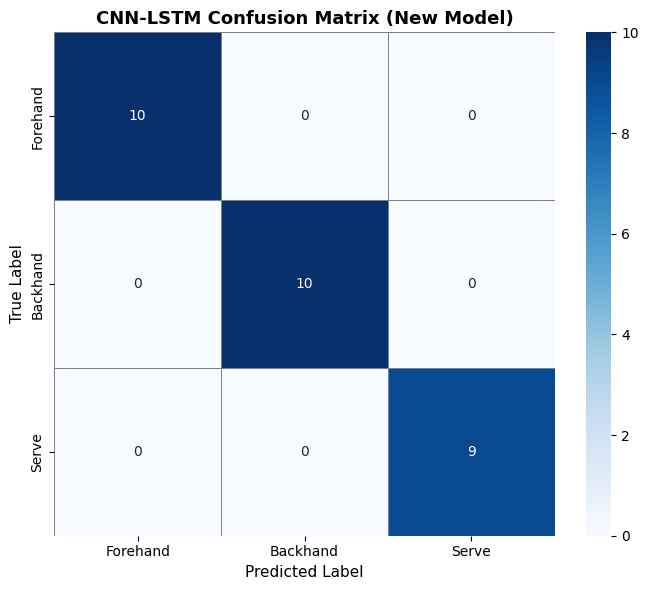

✅ Saved: confusion_matrix_cnn_lstm.png


In [ ]:
y_pred = np.argmax(model.predict(X_val), axis=1)
LABEL_NAMES = ["Forehand", "Backhand", "Serve"]

print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_val, y_pred, target_names=LABEL_NAMES))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, linecolor='gray')
plt.title("CNN-LSTM Confusion Matrix (New Model)", fontsize=13, fontweight='bold')
plt.ylabel("True Label", fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix_cnn_lstm.png", dpi=150)
plt.show()
print(" Saved: confusion_matrix_cnn_lstm.png")

CELL 8

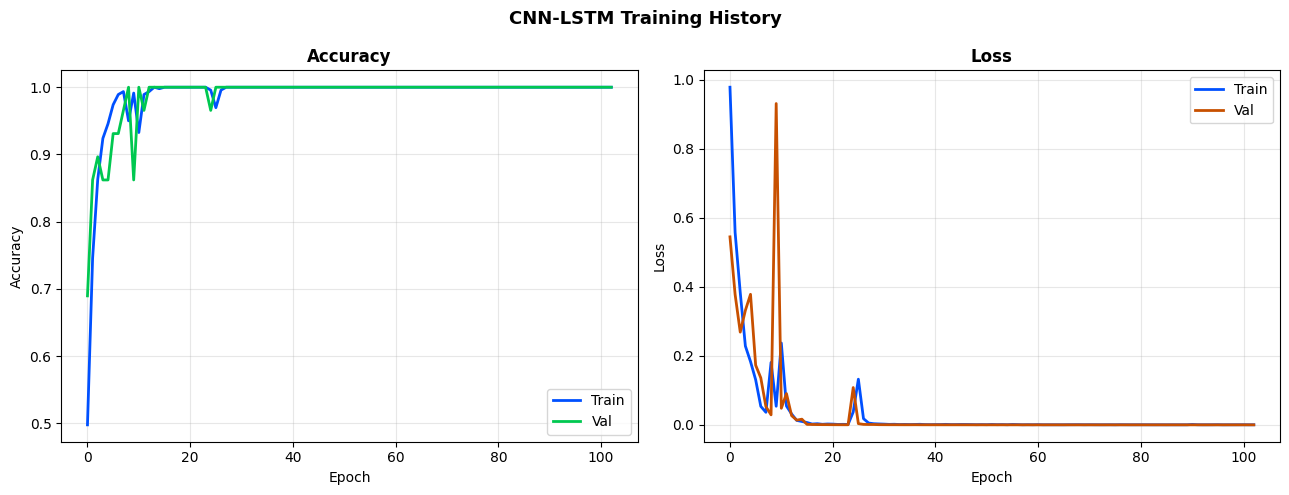

✅ Saved: training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='#0050FF', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='#00C850', linewidth=2)
axes[0].set_title("Accuracy", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='#0050FF', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='#C85000', linewidth=2)
axes[1].set_title("Loss", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("CNN-LSTM Training History", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print(" Saved: training_curves.png")

CELL 9

In [ ]:
model.save("tennis_cnn_lstm_v1.h5")
print(" Model saved: tennis_cnn_lstm_v1.h5")

# Download all outputs
for fname in ["tennis_cnn_lstm_v1.h5", "confusion_matrix_cnn_lstm.png", "training_curves.png"]:
    files.download(fname)
    print(f"⬇️  Downloading: {fname}")

print("\n🎾 ALL DONE — You now have your CNN-LSTM model!")

✅ Model saved: tennis_cnn_lstm_v1.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading: tennis_cnn_lstm_v1.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading: confusion_matrix_cnn_lstm.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading: training_curves.png

🎾 ALL DONE — You now have your CNN-LSTM model!


CELL 10

In [ ]:
import numpy as np

print("="*60)
print("DATA DIAGNOSTIC")
print("="*60)


print(f"\n1. Raw X shape: {X.shape}")
print(f"   Labels: F={np.sum(y==0)}  B={np.sum(y==1)}  S={np.sum(y==2)}")

print(f"\n2. Sample values from X[0] (first forehand clip, first 3 frames):")
print(X[0][:3])

print(f"\n3. Are any clips identical? (checking for duplicates)")

diffs = [np.mean(np.abs(X[0] - X[i])) for i in range(1, len(X))]
near_zero = sum(1 for d in diffs if d < 0.001)
print(f"   Clips nearly identical to X[0]: {near_zero}")

print(f"\n4. Value ranges per class:")
for label, name in [(0,"Forehand"),(1,"Backhand"),(2,"Serve")]:
    clips = X[y==label]
    print(f"   {name}: min={clips.min():.4f}  max={clips.max():.4f}  mean={clips.mean():.4f}  std={clips.std():.4f}")

print(f"\n5. Are Forehand and Backhand clips distinguishable?")
fh = X[y==0].mean(axis=0)
bh = X[y==1].mean(axis=0)
diff = np.mean(np.abs(fh - bh))
print(f"   Mean absolute difference between avg Forehand vs Backhand: {diff:.6f}")
print(f"   (If this is near 0, the classes look identical to the model)")

print(f"\n6. Train/Val split check:")
print(f"   X_train: {X_train.shape}  y_train counts: F={np.sum(y_train==0)}  B={np.sum(y_train==1)}  S={np.sum(y_train==2)}")
print(f"   X_val:   {X_val.shape}    y_val counts:   F={np.sum(y_val==0)}    B={np.sum(y_val==1)}    S={np.sum(y_val==2)}")

print(f"\n7. Sample forehand clip wrist trajectory (joint 0, x coord):")
print(np.round(X[y==0][0][:, 0], 4))

print(f"\n8. Sample backhand clip wrist trajectory (joint 0, x coord):")
print(np.round(X[y==1][0][:, 0], 4))

DATA DIAGNOSTIC

1. Raw X shape: (144, 30, 22)
   Labels: F=48  B=49  S=47

2. Sample values from X[0] (first forehand clip, first 3 frames):
[[ 4.4400308e-02 -8.2922935e-02  4.2075571e-02 -7.6030098e-02
   2.6040845e-02 -1.6071546e-01  2.7282536e-02 -1.2400602e-01
   1.8718196e-02 -1.2669794e-01  1.6128014e-04 -1.8302292e-01
   1.1458086e-02  1.1095628e-03 -1.1458086e-02 -1.1095628e-03
   3.7542548e-02  1.0113226e-01 -1.0109758e-03  1.0577905e-01
   1.5115695e-02 -2.2554116e-01]
 [ 6.5970555e-02 -9.8915391e-02  4.3960359e-02 -8.4049284e-02
   2.3793185e-02 -1.5899226e-01  6.9630072e-02 -1.5355204e-01
   3.9556377e-02 -1.4163324e-01  1.5794775e-02 -1.8274166e-01
   7.5341254e-03  2.2081581e-03 -7.5341254e-03 -2.2081581e-03
   4.8591767e-02  9.4335899e-02  2.1318559e-02  1.0413740e-01
   2.8829528e-02 -2.1590048e-01]
 [ 7.0473030e-02 -1.0394247e-01  4.2127773e-02 -8.6332232e-02
   2.2828097e-02 -1.6338928e-01  6.2603280e-02 -1.4868863e-01
   4.1472062e-02 -1.3416256e-01  1.9900881e-02 -

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from google.colab import files


import os
if not os.path.exists("X.npy"):
    print("Upload X.npy and y.npy")
    uploaded = files.upload()

X = np.load("X.npy")
y = np.load("y.npy")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if y.ndim == 1 else np.argmax(y, axis=1)
)


preds = model.predict(X_val, verbose=0)
y_pred = np.argmax(preds, axis=1)


if y_val.ndim > 1:
    y_true = np.argmax(y_val, axis=1)
else:
    y_true = y_val.astype(int)


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Forehand', 'Backhand', 'Serve'],
            yticklabels=['Forehand', 'Backhand', 'Serve'],
            linewidths=0.5)
plt.title('CNN-LSTM Confusion Matrix — Validation Set', fontsize=13, pad=15)
plt.ylabel('Actual Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n" + classification_report(
    y_true, y_pred,
    target_names=['Forehand', 'Backhand', 'Serve']
))

files.download('confusion_matrix.png')
print(" Saved → confusion_matrix.png")

Upload X.npy and y.npy


KeyboardInterrupt: 